# M1.Ex1: Model Hours vs Marks

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [1]:
import pandas as pd
import sklearn


### Step 1. Load the data

In [2]:
# pd.read_csv("../../../datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv").head()
url ="https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv"
db = pd.read_csv(url)
db.head()


,Hours_Studied,Marks
0,4.76,46.27
1,3.00,34.30
2,2.08,33.63
3,4.04,47.81
4,9.49,66.26


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X= db[['Hours_Studied']]
y= db['Marks']

### Step 2.b print the type of each

In [14]:
print('type x',X.dtypes)


type x Hours_Studied    float64
dtype: object


In [10]:
print('type y',y.dtypes)

type y float64


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

the target is numerical because it is continuous numbers the task is regression because it is categorical.

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [16]:
print(X.shape)
print(y.shape)

(100, 1)
(100,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [17]:
db.describe()

,Hours_Studied,Marks
count,100.000000,100.000000
mean,5.376300,46.360200
std,2.593013,14.284805
min,1.050000,20.190000
25%,3.175000,33.675000
50%,5.565000,47.485000
75%,7.255000,57.377500
max,9.870000,73.260000


### Step 5. Plot the feature vs the target

Text(0, 0.5, 'Marks')

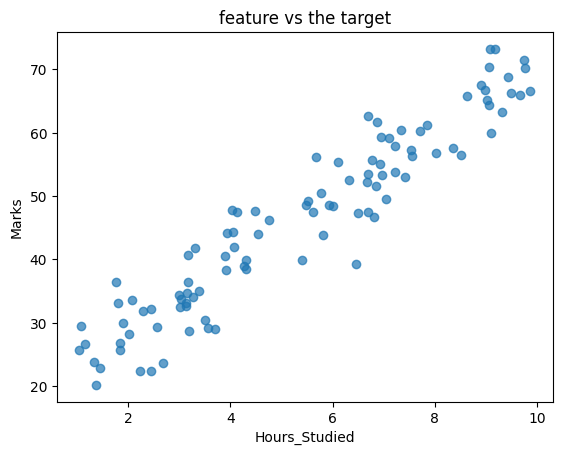

In [28]:
import statistics as sns
import matplotlib.pyplot as plt
plt.title('feature vs the target')
plt.scatter(db['Hours_Studied'], db['Marks'],alpha=0.7)

plt.xlabel('Hours_Studied')
plt.ylabel('Marks')


### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

The relationship is a direct correlation: the more hours studied (Feature), the higher the grades (Target).

### Step 7. Initialize a `LinearRegression` model

In [29]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    )



### Step 9.a Train the model on the training set

In [32]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Step 9.b Identify the learned slope and the y-intercept of the model

In [36]:
slop= model.coef_[0]
intercept = model.intercept_
print(slop)
print(intercept)

5.164438413499556
18.538578512317276


### Step 9.c how much marks do we get per 1 hour of study?

we got 5.164438413499556 slop for each 1 hour of study.

### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [37]:
ten= (slop*10)/60
print(f"Every 10 minutes of study adds approximately {ten:.2f} marks.")

Every 10 minutes of study adds approximately 0.86 marks.


### Step 9.e if one doesn't study at all, how much marks do they get?

In [39]:
zero_study= intercept
print(f"If a student doesn't study at all, they are expected to get: {zero_study:.2f} marks.")

If a student doesn't study at all, they are expected to get: 18.54 marks.


### Step 10. Evaluate the model on the test set

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [42]:
import pandas as pd


sample_X = X_test.head(3)
sample_y = y_test.head(3)


sample_predictions = model.predict(sample_X)

results = pd.DataFrame({
    'Actual Marks (y_test)': sample_y.values,
    'Predicted Marks (y_pred)': sample_predictions.round(2)
})

print("Sample Comparison:")
print(results)

Sample Comparison:
   Actual Marks (y_test)  Predicted Marks (y_pred)
0                  32.50                     34.14
1                  67.54                     64.50
2                  55.70                     53.55


### Step 12. Plot the data and the regression line

Text(0, 0.5, 'Marks')

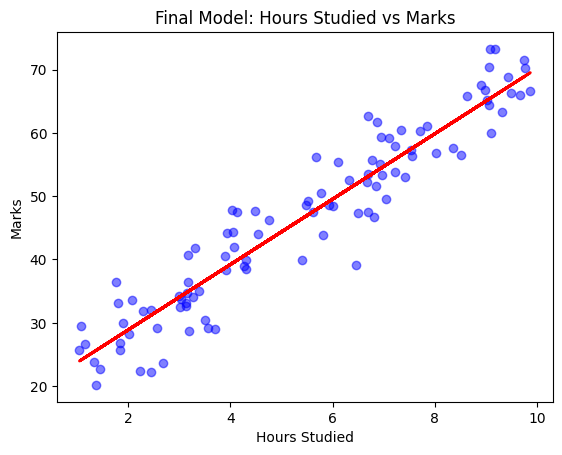

In [43]:
import matplotlib.pyplot as plt


plt.scatter(X, y, color='blue', label='Actual Data', alpha=0.5)


plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')

plt.title('Final Model: Hours Studied vs Marks')
plt.xlabel('Hours Studied')
plt.ylabel('Marks')